# APL-Diffusion — Section 6.1 Experiment

**Paper:** Jin, Xu, Yang (2025) — *Adaptive Partitioning and Learning for Stochastic Control of Diffusion Processes*, arXiv:2512.14991

This notebook imports `apl_diffusion_full.py` as a library and runs each step of the experiment independently. Nothing executes on import — every cell is opt-in.

**File must be in the same directory as this notebook.**

---
### Structure
| Cell | What it does |
|------|-------------|
| 1 | Imports and configuration |
| 2 | Bellman solver → V\*(x₀) |
| 3 | MC constant-policy lower bound |
| 4 | Run APL-Diffusion experiments |
| 5 | Partition heatmap |
| 6 | Regret plots + slope summary |

## Cell 1 — Imports and configuration

In [5]:
import time
import numpy as np

from aaro_again import (
    # Reward functions — pick one for REWARD_FN below
    reward_6_1,                   # (x-a)^2          Section 6.1 baseline
    reward_quadratic_asymmetric,  # (x-a)^2*(1+|x|)  spatially non-uniform gap
    reward_quadratic_shifted,     # (x-a-0.5)^2      non-trivial optimal policy
    reward_quartic,               # (x-a)^4          m=3, flat well near optimum
    # Core classes
    AdaDiffEnvironment, APLDiffusion, Experiment,
    BellmanSolverScalar,
    compute_vstar_gh, compute_best_constant,
    run_experiments, cumulative_regret, regret_slope,
    plot_all, plot_partition_heatmap,
    N_EPS, EP_LEN, STARTING_STATE,
)

# ╔══════════════════════════════════════════════════════════════════╗
# ║                  EDIT THIS CELL ONLY                           ║
# ╚══════════════════════════════════════════════════════════════════╝

# ── 1. Reward function ───────────────────────────────────────────────────────
# Swap this to change the experiment. Everything downstream updates automatically.
#
#   reward_6_1                  ->  (x-a)^2            baseline (Section 6.1)
#   reward_quadratic_asymmetric ->  (x-a)^2*(1+|x|)    non-uniform zooming dim
#   reward_quadratic_shifted    ->  (x-a-0.5)^2        shifted optimal action
#   reward_quartic              ->  (x-a)^4            m=3, larger zooming dim
#
REWARD_FN = reward_6_1

# ── 2. Solver resolution ─────────────────────────────────────────────────────
# Peak RAM = n_state * n_action * n_quad * 24 bytes
# 8 GB machine:  801 / 401 / 61  ->  0.47 GB  safe
# 16 GB machine: 1601 / 801 / 121 -> 3.70 GB  higher accuracy
N_STATE   = 801
N_ACTION  = 401
N_QUAD    = 61

# ── 3. Experiment size ───────────────────────────────────────────────────────
N_EXPERIMENTS = 20   # parallel APL-Diffusion runs  (paper used 10+)
FIT_START     = 1000 # episode from which to fit log-log slope

# ── 4. Optional dynamics overrides ──────────────────────────────────────────
# Uncomment and edit to change dynamics without touching the library.
import aaro_again as _apl
_apl.DRIFT_BIAS    = 0.05
_apl.DRIFT_STATE   = -0.10
_apl.DRIFT_ACTION  = 0.01
_apl.SIGMA         = 0.10
_apl.INITIAL_Q     = 1837.1
_apl.SCALING       = 0.5

# ── Summary ──────────────────────────────────────────────────────────────────
peak_gb = N_STATE * N_ACTION * N_QUAD * 24 / 1e9
print(f'Reward function : {REWARD_FN.__name__}')
print(f'Reward doc      : {REWARD_FN.__doc__.strip().splitlines()[0]}')
print(f'Solver          : {N_STATE} states x {N_ACTION} actions x {N_QUAD} quad pts')
print(f'Peak solver RAM : ~{peak_gb:.2f} GB')
print(f'Experiments     : {N_EXPERIMENTS} parallel runs x {N_EPS} episodes')


Reward function : reward_6_1
Reward doc      : R ~ N((x-a)^2, 0.01).  Baseline from Section 6.1.
Solver          : 801 states x 401 actions x 61 quad pts
Peak solver RAM : ~0.47 GB
Experiments     : 20 parallel runs x 2000 episodes


## Cell 2 — Bellman solver: V\*(x₀)

Runs backward induction with vectorised Gauss-Hermite quadrature.
This is the reference line for the regret plots.

**Runtime:** ~2 min on a 2017 MacBook Air at full resolution.

In [6]:
# BellmanSolverScalar is the fast vectorised solver.
# compute_vstar_gh() now delegates here, but calling directly is cleaner.
t0 = time.perf_counter()

solver    = BellmanSolverScalar(ep_len=EP_LEN,
                                n_state=N_STATE,
                                n_action=N_ACTION,
                                n_quad=N_QUAD)
solver.solve()
v_star_gh = solver.get_value(STARTING_STATE, h=0)

print(f'V*(x0={STARTING_STATE}) = {v_star_gh:.6f}')
print(f'Solver time: {time.perf_counter() - t0:.1f}s')


V*(x0=4.0) = 474.863579
Solver time: 23.1s


## Cell 3 — MC constant-policy lower bound

Computes the value of the best *constant* action via Monte Carlo.
This is a lower bound on V\* because the true optimal policy is state-dependent.
Useful as a sanity check: the gap shows how much the adaptive policy gains.

In [7]:
t0 = time.perf_counter()

v_star_mc, best_action = compute_best_constant(
    n_actions = 201,
    n_mc      = 50_000,
    x0        = STARTING_STATE,
)

print(f"Best constant action:    a* = {best_action:.2f}")
print(f"V^const(x0)            = {v_star_mc:.6f}")
print(f"V*(x0) [GH solver]     = {v_star_gh:.6f}")
print(f"Gap (state-dep. gain)  = {v_star_gh - v_star_mc:.4f}")
print(f"Time: {time.perf_counter() - t0:.1f}s")

Best constant action:    a* = 10.00
V^const(x0)            = 474.847224
V*(x0) [GH solver]     = 474.863579
Gap (state-dep. gain)  = 0.0164
Time: 119.1s


## Cell 4 — Run APL-Diffusion experiments

Runs `N_EXPERIMENTS` independent APL-Diffusion agents in parallel.
Returns a `(N_EPS, N_EXPERIMENTS)` matrix of episode rewards.

**Runtime:** ~2 min on a 2017 MacBook Air for N_EXPERIMENTS=20.

In [8]:
t0 = time.perf_counter()

vpi_matrix = run_experiments(n=N_EXPERIMENTS)   # shape (N_EPS, N_EXPERIMENTS)

mean_final = vpi_matrix[-100:].mean()           # avg reward over last 100 episodes
print(f"{N_EXPERIMENTS} experiments x {N_EPS} episodes complete [{time.perf_counter()-t0:.1f}s]")
print(f"Mean episode reward (last 100 eps): {mean_final:.2f}")
print(f"V*(x0) for reference:               {v_star_gh:.2f}")

20 experiments x 2000 episodes complete [434.5s]
Mean episode reward (last 100 eps): 338.21
V*(x0) for reference:               474.86


## Cell 5 — Partition heatmap

Trains one agent and plots the Q-value heatmap of its adaptive partition
at the final timestep — reproduces Figure 2 from the paper.

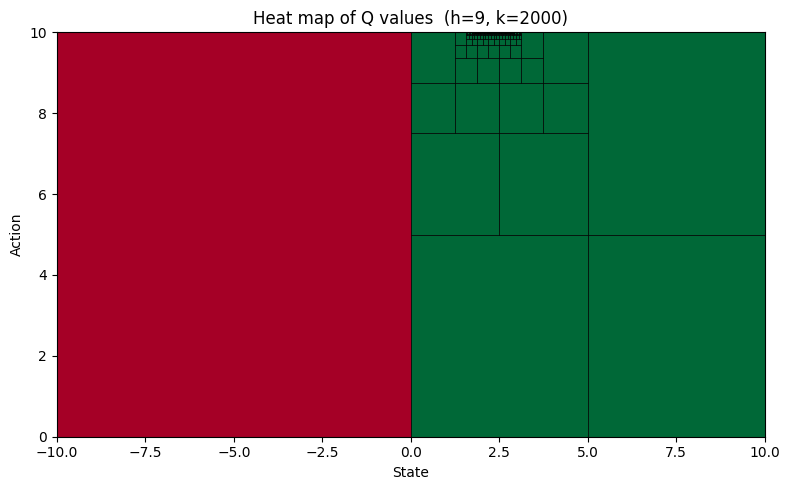

In [9]:
env_vis   = AdaDiffEnvironment()
agent_vis = APLDiffusion(flag=True)
Experiment(env_vis, agent_vis, n_eps=N_EPS, seed=123).run()

plot_partition_heatmap(agent_vis, timestep=EP_LEN - 1)

## Cell 6 — Regret plots and slope

Produces the three-panel figure:
- **(a)** Learning curve with ±1σ band
- **(b)** Log-log cumulative regret vs episode — slope = regret exponent α
- **(c)** Slope comparison against theoretical worst-case bound (3/4)

The slope against the GH solver is the number comparable to Figure 3(b) of the paper (reported as ≈ 0.69).

Figure saved to apl_regret_analysis.png


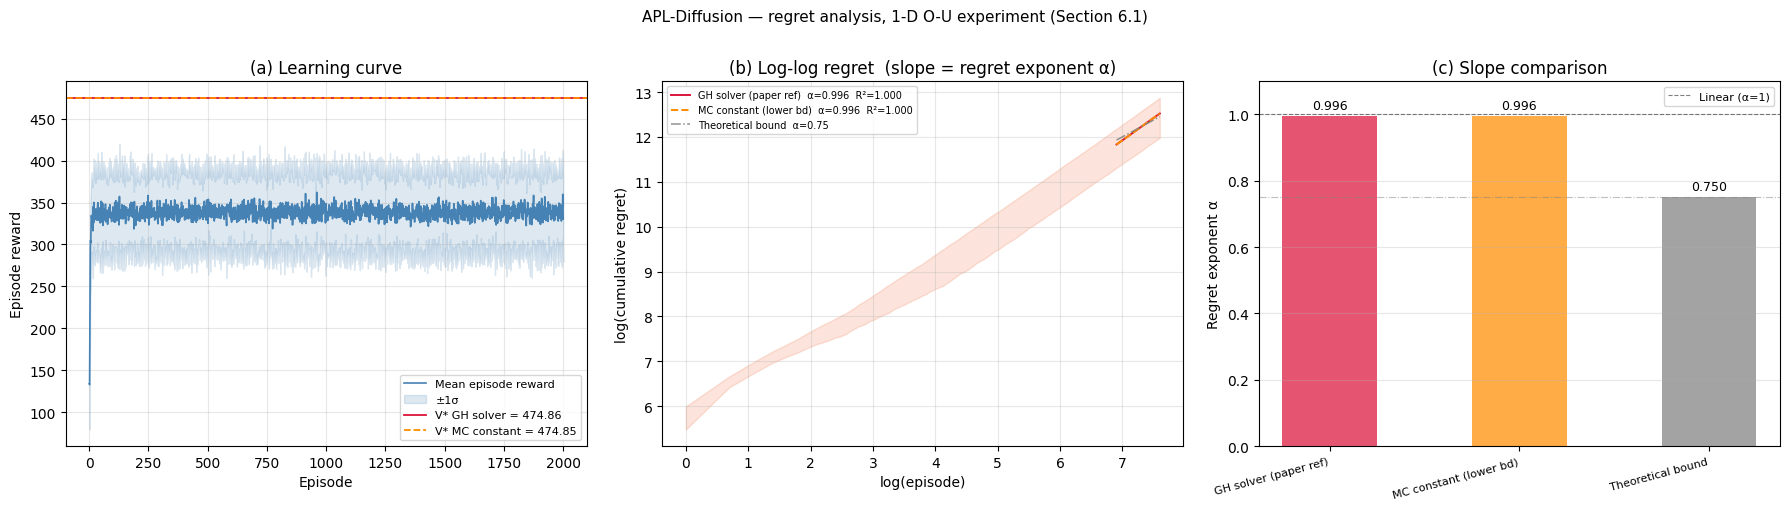


── Regret slope summary ─────────────────────────────────
  GH solver (paper ref)         α = 0.9962  ← compare with paper
  MC constant (lower bd)        α = 0.9962
  Theoretical worst-case bound     α = 0.7500  (Theorem 5.19)
  Paper Figure 3(b) reports        α ≈ 0.6900

  ✗ slope >= 0.75  (slope = 0.9962)


In [10]:
slopes = plot_all(
    vpi_matrix = vpi_matrix,
    v_star_gh  = v_star_gh,
    v_star_mc  = v_star_mc,
    fit_start  = FIT_START,
)

print("\n── Regret slope summary ─────────────────────────────────")
for name, sl in slopes.items():
    tag = "  ← compare with paper" if "GH" in name else ""
    print(f"  {name:<28s}  α = {sl:.4f}{tag}")
print(f"  Theoretical worst-case bound     α = 0.7500  (Theorem 5.19)")
print(f"  Paper Figure 3(b) reports        α ≈ 0.6900")

gh_slope = slopes.get('GH solver (paper ref)', float('nan'))
status = "✓ sublinear regret confirmed" if gh_slope < 0.75 else "✗ slope >= 0.75"
print(f"\n  {status}  (slope = {gh_slope:.4f})")

Figure saved to apl_regret_analysis.png


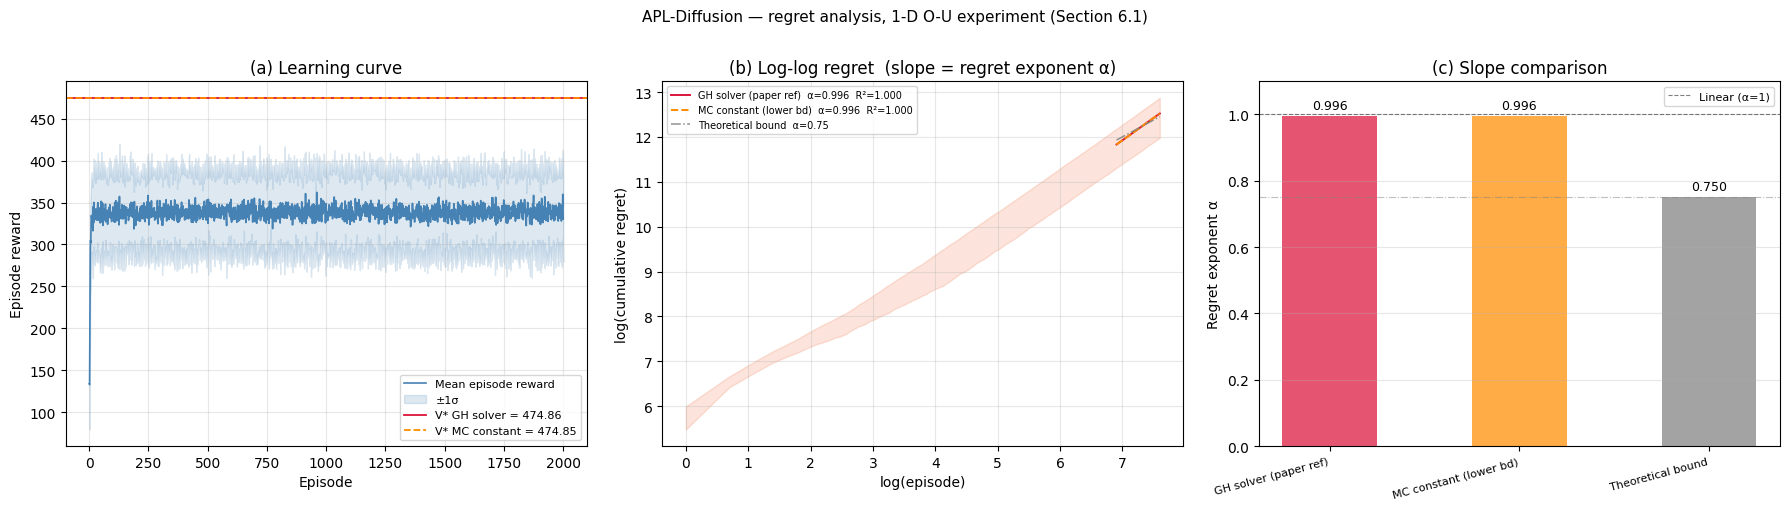

In [11]:
import matplotlib.pyplot as plt
slopes = plot_all(vpi_matrix, v_star_gh, v_star_mc, fit_start=FIT_START)

# If you want to see the full curve instead:
# fig = plt.gcf()
# fig.axes[1].set_xlim(left=0)
# plt.draw()

## Optional — manual regret inspection

In [12]:
# Compute regret arrays directly if you want to inspect or replot manually
cum_mean, cum_lo, cum_hi = cumulative_regret(vpi_matrix, v_star_gh)
slope, intercept, r2     = regret_slope(cum_mean, fit_start=FIT_START)

print(f"Cumulative regret at K={N_EPS}: {cum_mean[-1]:.1f}")
print(f"Log-log slope α = {slope:.4f}  (R² = {r2:.4f})")

Cumulative regret at K=2000: 274298.6
Log-log slope α = 0.9962  (R² = 1.0000)
